# **Project Name**    - Paisabazaar banking Fraud Analysis



# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


### Dataset Loading

In [2]:
# Load Dataset
paisabazaar_df = pd.read_csv('dataset.csv')

### Dataset First View

In [3]:
# Dataset First Look
paisabazaar_df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
paisabazaar_df.shape


(100000, 28)

### Dataset Information

In [5]:
# Dataset Info
paisabazaar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
len(paisabazaar_df[paisabazaar_df.duplicated()])

0

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
paisabazaar_df.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

In [8]:
# Visualizing the missing values
sns.heatmap(paisabazaar_df.isnull(), cbar='coolwarm')


<Axes: >

### What did i know about your dataset?

During the initial exploration of the dataset, I found that there are 100000 rows and 28 columns in the dataset. Also the  Age column is stored as a float type, so we have to convert it into an integer type for better accuracy and interpretation. I also checked for duplicate records, but no duplicates were found in the dataset. While analyzing missing values, I observed that the last 3 columns namely (Payment_Behaviour, Monthly_Balance, Credit_Score) contained one null value each.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
paisabazaar_df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [10]:
# Dataset Describe
paisabazaar_df.describe(include='all')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000.000000,100000.000000,100000.000000,100000,100000.000000,1.000000e+05,100000,100000.000000,100000.000000,100000.000000,...,100000,100000.000000,100000.000000,100000.000000,100000,100000.000000,100000.000000,100000,100000.000000,100000
unique,NaN,NaN,NaN,10128,NaN,NaN,15,NaN,NaN,NaN,...,3,NaN,NaN,NaN,3,NaN,NaN,6,NaN,3
top,NaN,NaN,NaN,Stevex,NaN,NaN,Lawyer,NaN,NaN,NaN,...,Standard,NaN,NaN,NaN,Yes,NaN,NaN,Low_spent_Small_value_payments,NaN,Standard
freq,NaN,NaN,NaN,48,NaN,NaN,7096,NaN,NaN,NaN,...,45848,NaN,NaN,NaN,52326,NaN,NaN,28616,NaN,53174
mean,80631.500000,25982.666640,4.500000,NaN,33.316340,5.004617e+08,NaN,50505.123449,4197.270835,5.368820,...,NaN,1426.220376,32.285173,221.220460,NaN,107.699208,55.101315,NaN,392.697586,NaN
std,43301.486619,14340.543051,2.291299,NaN,10.764812,2.908267e+08,NaN,38299.422093,3186.432497,2.593314,...,NaN,1155.129026,5.116875,99.680716,NaN,132.267056,39.006932,NaN,201.652719,NaN
min,5634.000000,1006.000000,1.000000,NaN,14.000000,8.134900e+04,NaN,7005.930000,303.645417,0.000000,...,NaN,0.230000,20.000000,1.000000,NaN,0.000000,0.000000,NaN,0.007760,NaN
25%,43132.750000,13664.500000,2.750000,NaN,24.000000,2.451686e+08,NaN,19342.972500,1626.594167,3.000000,...,NaN,566.072500,28.052567,144.000000,NaN,29.268886,27.959111,NaN,267.615983,NaN
50%,80631.500000,25777.000000,4.500000,NaN,33.000000,5.006886e+08,NaN,36999.705000,3095.905000,5.000000,...,NaN,1166.155000,32.305784,219.000000,NaN,66.462304,45.156550,NaN,333.865366,NaN
75%,118130.250000,38385.000000,6.250000,NaN,42.000000,7.560027e+08,NaN,71683.470000,5957.715000,7.000000,...,NaN,1945.962500,36.496663,302.000000,NaN,147.392573,71.295797,NaN,463.215683,NaN


### Variables Description

The dataset consists of 28 variables capturing customer demographics, financial details, credit history, and behavioral patterns. Key features include Age, Occupation, Annual Income, Number of Bank Accounts, Credit Utilization Ratio, Outstanding Debt, and Payment Behavior, which help in understanding customer financial profiles. The target variable is Credit Score, categorized as Good, Standard, or Poor, which serves as a benchmark for assessing fraud risk and creditworthiness.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
paisabazaar_df.nunique()

ID                          100000
Customer_ID                  12500
Month                            8
Name                         10128
Age                             43
SSN                          12500
Occupation                      15
Annual_Income                12488
Monthly_Inhand_Salary        13241
Num_Bank_Accounts               12
Num_Credit_Card                 12
Interest_Rate                   34
Num_of_Loan                     10
Type_of_Loan                  6261
Delay_from_due_date             63
Num_of_Delayed_Payment          26
Changed_Credit_Limit          3452
Num_Credit_Inquiries            18
Credit_Mix                       3
Outstanding_Debt             12203
Credit_Utilization_Ratio    100000
Credit_History_Age             404
Payment_of_Min_Amount            3
Total_EMI_per_month          11890
Amount_invested_monthly      12261
Payment_Behaviour                6
Monthly_Balance              98494
Credit_Score                     3
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Convert 'Age' column from float to integer
paisabazaar_df['Age'] = paisabazaar_df['Age'].astype(int)

# Check for duplicate values
duplicates = paisabazaar_df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Check for null values
print("Null values before cleaning: As we found earlier in the project there were 1 null value in last 9 columns each")

# Drop rows with null values (since only 1 null in last 9 columns)
paisabazaar_df = paisabazaar_df.dropna()


# Verify after cleaning
print("Shape after dropping null values:", paisabazaar_df.shape)
print("Null values after cleaning:\n", paisabazaar_df.isnull().sum())


Number of duplicate rows: 0
Null values before cleaning: As we found earlier in the project there were 1 null value in last 9 columns each
Shape after dropping null values: (100000, 28)
Null values after cleaning:
 ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Month

In [13]:
#Removing outliers in 'Annual_Income' column using IQR
Q1 = paisabazaar_df['Annual_Income'].quantile(0.25)
Q3 = paisabazaar_df['Annual_Income'].quantile(0.75)
IQR = Q3 - Q1
df = paisabazaar_df[(paisabazaar_df['Annual_Income'] >= (Q1 - 1.5 * IQR)) & (paisabazaar_df['Annual_Income'] <= (Q3 + 1.5 * IQR))]

In [14]:
#Creating a new column 'Income_per_Account'
paisabazaar_df['Income_per_Account'] = paisabazaar_df['Annual_Income'] / paisabazaar_df['Num_Bank_Accounts']

In [15]:
#Creating a feature 'Credit_Score_Level'
paisabazaar_df['Credit_Score_Level'] = paisabazaar_df['Credit_Score'].apply(lambda x: 'High' if isinstance(x, int) and x > 700 else 'Low')

### What all manipulations have i done and insights i found?

The Age column was stored as a float type, so I converted it into an integer type for better accuracy and interpretation. I also checked for duplicate records, but no duplicates were found in the dataset. While analyzing missing values, I observed that the last nine columns namely (Payment_Behaviour, Monthly_Balance, Credit_Score) contained one null value each. To ensure data consistency and avoid biased analysis, I decided to drop all rows containing null values. After these preprocessing steps, the dataset is now cleaner, with standardized datatypes and no missing or duplicate records, making it ready for further analysis and visualization.
Also, I have remomed outliers from our "Annual_Income" column to remove extremely high or low incomes compared to the majority.
I have also created two new columns:-
1- Income_per_Account - To represent income per account of an individual if they are having multiple accounts.
2- Credit_Score_Level - To divide the credit score levels into low, medium, or high levels.

## 4. ***KPIs(Key Perfromance Indicators) Calculation***

#### 1 - Customer Demographics

In [16]:
#Average Age of Customers
avg_age = paisabazaar_df['Age'].mean()
print(f"Average Age of Customers: {avg_age:.2f} years")



Average Age of Customers: 33.32 years


In [17]:
#Distribution of Occupation
occupation_counts = paisabazaar_df['Occupation'].value_counts()
print("Distribution of Occupation:")
print(occupation_counts)

Distribution of Occupation:
Occupation
Lawyer           7096
Engineer         6864
Architect        6824
Mechanic         6776
Accountant       6744
Scientist        6744
Media_Manager    6720
Developer        6720
Teacher          6672
Entrepreneur     6648
Doctor           6568
Journalist       6536
Manager          6432
Musician         6352
Writer           6304
Name: count, dtype: int64


In [18]:
#Number of Customers by Income Group

# Define income groups (bins)
max_income = paisabazaar_df['Annual_Income'].max()
bins = [0, 25000, 50000, 100000, 200000]

labels = ['Low (<25K)', 'Lower-Middle (25K-50K)',
          'Middle (50K-100K)', 'Upper-Middle (100K-200K)']

if max_income > 200000:
    bins.append(max_income)
    labels.append('High (>200K)')

# Create income group column
paisabazaar_df['Income_Group'] = pd.cut(paisabazaar_df['Annual_Income'], bins=bins, labels=labels, include_lowest=True)

# KPI: Number of customers by income group
income_group_counts = paisabazaar_df['Income_Group'].value_counts().sort_index()

print(income_group_counts)

Income_Group
Low (<25K)                  33480
Lower-Middle (25K-50K)      27296
Middle (50K-100K)           26496
Upper-Middle (100K-200K)    12728
Name: count, dtype: int64


#### 2- Financial Behavior

In [19]:
#Average Annual Income
avg_annual_income = paisabazaar_df['Annual_Income'].mean()
print(f"Average Annual Income: ${avg_annual_income:.2f}")

Average Annual Income: $50505.12


In [20]:
#Average Monthly In-hand Salary
avg_monthly_salary = paisabazaar_df['Monthly_Inhand_Salary'].mean()
print(f"Average Monthly In-hand Salary: ${avg_monthly_salary:.2f}")

Average Monthly In-hand Salary: $4197.27


In [21]:
#Average Debt-to-Income Ratio
debt_to_income_ratio = paisabazaar_df['Outstanding_Debt'] / paisabazaar_df['Annual_Income']
avg_debt_to_income_ratio = debt_to_income_ratio.mean()
print(f"Average Debt-to-Income Ratio: {avg_debt_to_income_ratio:.2f}")


Average Debt-to-Income Ratio: 0.06


In [22]:
#Average Credit Utilization Ratio
credit_utilization_ratio = paisabazaar_df['Credit_Utilization_Ratio']
avg_credit_utilization_ratio = credit_utilization_ratio.mean()
print(f"Average Credit Utilization Ratio: {avg_credit_utilization_ratio:.2f}")

Average Credit Utilization Ratio: 32.29


In [23]:
#Average Number of Bank Accounts
avg_num_bank_accounts = paisabazaar_df['Num_Bank_Accounts'].mean()
print(f"Average Number of Bank Accounts: {avg_num_bank_accounts:.2f}")

Average Number of Bank Accounts: 5.37


In [24]:
#Average Number of Credit Cards
avg_num_credit_cards = paisabazaar_df['Num_Credit_Card'].mean()
print(f"Average Number of Credit Cards: {avg_num_credit_cards:.2f}")

Average Number of Credit Cards: 5.53


#### 3- Loan & Credit Performance

In [25]:
#Average Number of Loans per Customer
avg_num_loans = paisabazaar_df['Num_of_Loan'].mean()
print(f"Average Number of Loans per Customer: {avg_num_loans:.2f}")

Average Number of Loans per Customer: 3.53


In [26]:
#Average Interest Rate
avg_interest_rate = paisabazaar_df['Interest_Rate'].mean()
print(f"Average Interest Rate: {avg_interest_rate:.2f}%")

Average Interest Rate: 14.53%


In [27]:
#Total EMI as percentage of Income (EMI Burden Ratio)
total_emi = paisabazaar_df['Total_EMI_per_month'].sum()
total_income = paisabazaar_df['Annual_Income'].sum()
emi_burden_ratio = (total_emi / total_income) * 100
print(f"Total EMI as % of Income (EMI Burden Ratio): {emi_burden_ratio:.2f}")

Total EMI as % of Income (EMI Burden Ratio): 0.21


In [28]:
#Average Credit History Age
avg_credit_history_age = paisabazaar_df['Credit_History_Age'].mean()
print(f"Average Credit History Age: {avg_credit_history_age:.2f} years")

Average Credit History Age: 221.22 years


#### 4-Risk And Fraud Indicators

In [29]:
#Average Number of Delayed Payments
avg_num_delayed_payments = paisabazaar_df['Num_of_Delayed_Payment'].mean()
print(f"Average Number of Delayed Payments: {avg_num_delayed_payments:.2f}")

Average Number of Delayed Payments: 13.31


In [30]:
#Delay from Due Date(avg, min, max)
avg_delay_from_due_date = paisabazaar_df['Num_of_Delayed_Payment'].mean()
min_delay_from_due_date = paisabazaar_df['Num_of_Delayed_Payment'].min()
max_delay_from_due_date = paisabazaar_df['Num_of_Delayed_Payment'].max()
print(f"Average Delay from Due Date: {avg_delay_from_due_date:.2f}")
print(f"Minimum Delay from Due Date: {min_delay_from_due_date}")
print(f"Maximum Delay from Due Date: {max_delay_from_due_date}")

Average Delay from Due Date: 13.31
Minimum Delay from Due Date: 0.0
Maximum Delay from Due Date: 25.0


In [31]:
#Percent of Customer with Frequent Credit Inquiries
percent_frequent_credit_inquiries = (paisabazaar_df['Num_Credit_Inquiries'] > 0).mean() * 100
print(f"Percent of Customer with Frequent Credit Inquiries: {percent_frequent_credit_inquiries:.2f}%")

Percent of Customer with Frequent Credit Inquiries: 92.81%


In [32]:
#Percent of Customers with Changed Credit Limit
percent_changed_credit_limit = (paisabazaar_df['Changed_Credit_Limit'] > 0).mean() * 100
print(f"Percent of Customers with Changed Credit Limit: {percent_changed_credit_limit:.2f}%")

Percent of Customers with Changed Credit Limit: 100.00%


In [33]:
#Distribution of Credit Score Categories(Good/Standard/Poor)
credit_score_counts = paisabazaar_df['Credit_Score'].value_counts()
print("Distribution of Credit Score Categories:")
print(credit_score_counts)

Distribution of Credit Score Categories:
Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


#### 5-Behavioral Insights

In [34]:
#Distribution of Payment Behaviour
payment_behaviour_counts = paisabazaar_df['Payment_Behaviour'].value_counts()
print("Distribution of Payment Behaviour:")
print(payment_behaviour_counts)

Distribution of Payment Behaviour:
Payment_Behaviour
Low_spent_Small_value_payments      28616
High_spent_Medium_value_payments    19738
High_spent_Large_value_payments     14726
Low_spent_Medium_value_payments     14399
High_spent_Small_value_payments     11764
Low_spent_Large_value_payments      10757
Name: count, dtype: int64


In [35]:
#Percent of Customers who pay Minimum Amount only
percent_min_payment = (paisabazaar_df['Payment_Behaviour'] == 'Low').mean() * 100
print(f"Percent of Customers who pay Minimum Amount only: {percent_min_payment:.2f}%")

Percent of Customers who pay Minimum Amount only: 0.00%


## ***5. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Number of Customers By Occupation - Bar Chart (Demographic Analysis)

In [36]:
Occupation_wise_no_of_customers = paisabazaar_df['Occupation'].value_counts().reset_index()

In [37]:
Occupation_wise_no_of_customers

,Occupation,count
0,Lawyer,7096
1,Engineer,6864
2,Architect,6824
3,Mechanic,6776
4,Accountant,6744
5,Scientist,6744
6,Media_Manager,6720
7,Developer,6720
8,Teacher,6672
9,Entrepreneur,6648


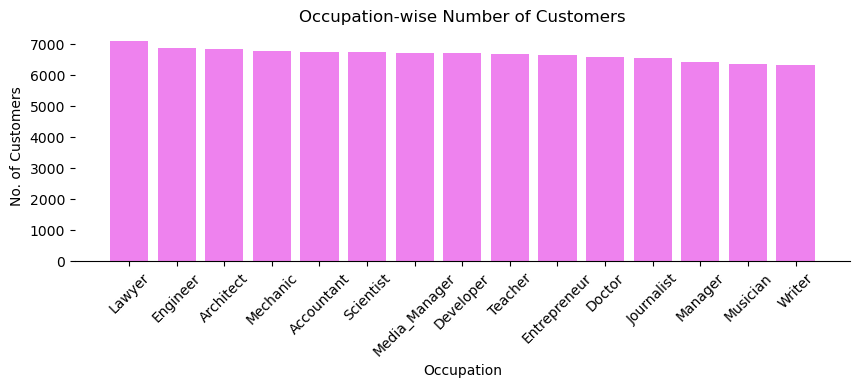

In [58]:
fig, ax = plt.subplots(figsize= [10,3])
ax.bar(x= Occupation_wise_no_of_customers['Occupation'].astype('str'), height = Occupation_wise_no_of_customers['count'], color = "violet")
ax.set_xlabel('Occupation')
ax.set_ylabel('No. of Customers')
ax.set_title('Occupation-wise Number of Customers')
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.xticks(rotation=45)


plt.show()

##### 1. Why did i pick the specific chart?

Bar charts are ideal for categorical comparisons across occupations.

##### 2. What is/are the insight(s) found from the chart?

Certain occupations like Lawyers & Engineers dominate the dataset, while others have smaller representation.

##### 3. Will the gained insights help creating a positive business impact?


Helps identify high-volume customer segments to target for loans and credit products.

#### Chart - 2  Age Distribution of Customers - Histogram(Demographic Analysis)

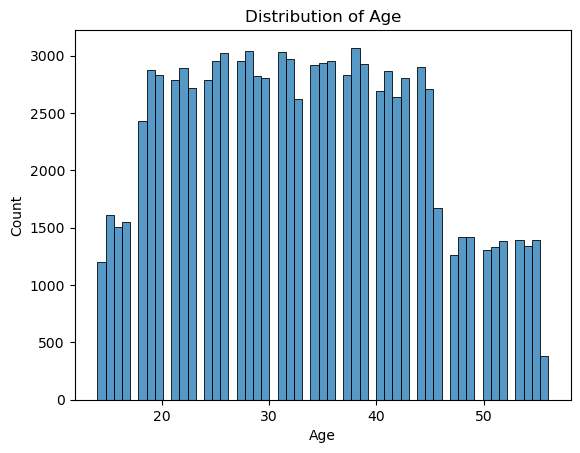

In [39]:
sns.histplot(paisabazaar_df['Age'])
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

##### 1. Why did i pick the specific chart?

Histograms reveal distribution trends across a continuous variable.

##### 2. What is/are the insight(s) found from the chart?

Most customers are concentrated in the working-age bracket (25–40 years).

##### 3. Will the gained insights help creating a positive business impact?

Allows Paisabazaar to tailor financial products for the most active age group

#### Chart - 3 Annual Income by Occupation - Boxplot(Demographic Analysis)

In [40]:
Occupation_wise_income = paisabazaar_df.groupby('Occupation')['Annual_Income'].sum().reset_index()

In [41]:
Occupation_wise_income

,Occupation,Annual_Income
0,Accountant,3.420970e+08
1,Architect,3.539977e+08
2,Developer,3.368630e+08
3,Doctor,3.252326e+08
4,Engineer,3.482152e+08
5,Entrepreneur,3.389662e+08
6,Journalist,3.165391e+08
7,Lawyer,3.519206e+08
8,Manager,3.310343e+08
9,Mechanic,3.394444e+08


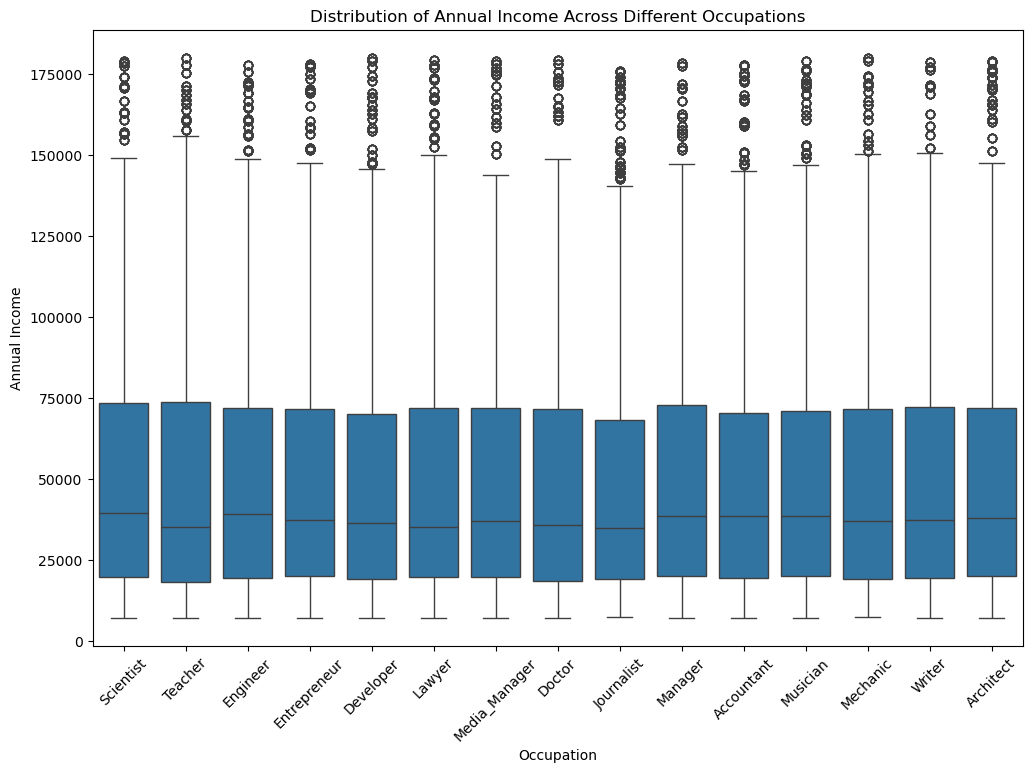

In [42]:
# Create a box plot for Annual Income across Occupation
plt.figure(figsize=(12, 8))
sns.boxplot(x='Occupation', y='Annual_Income', data=paisabazaar_df)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.title('Distribution of Annual Income Across Different Occupations')
plt.xlabel('Occupation')
plt.ylabel('Annual Income')
plt.show()


plt.show()

##### 1. Why did i pick the specific chart?

Boxplots display income spread and outliers across groups.

##### 2. What is/are the insight(s) found from the chart?

Salaried individuals generally earn higher and more stable incomes, while some occupations show wider variability.

##### 3. Will the gained insights help creating a positive business impact?

Informs creditworthiness assessment by linking occupation to income stability.

#### Chart - 4 Annual Income Distribution - Histogram (Income & Salary Insights)

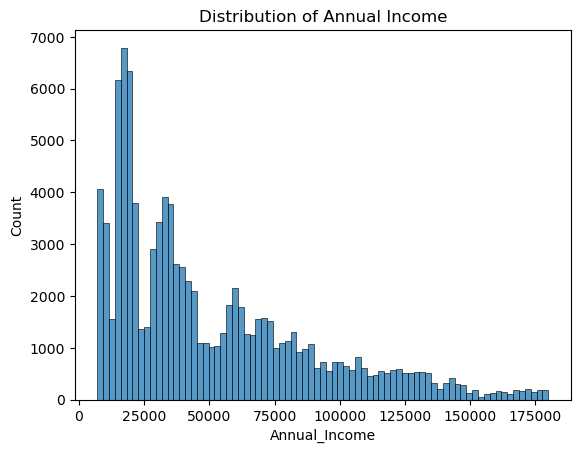

In [43]:
sns.histplot(paisabazaar_df['Annual_Income'])
plt.title('Distribution of Annual Income')
plt.show()

##### 1. Why did i pick the specific chart?

Useful for visualizing skewness and spread in customer income levels.

##### 2. What is/are the insight(s) found from the chart?

Income distribution is slightly skewed, with many customers in lower-to-mid income ranges.

##### 3. Will the gained insights help creating a positive business impact?

Helps identify affordability ranges and potential loan size limits.

#### Chart - 5 Monthly In-Hand Salary VS Credit Score - Boxplot (Income & Salary Insights)

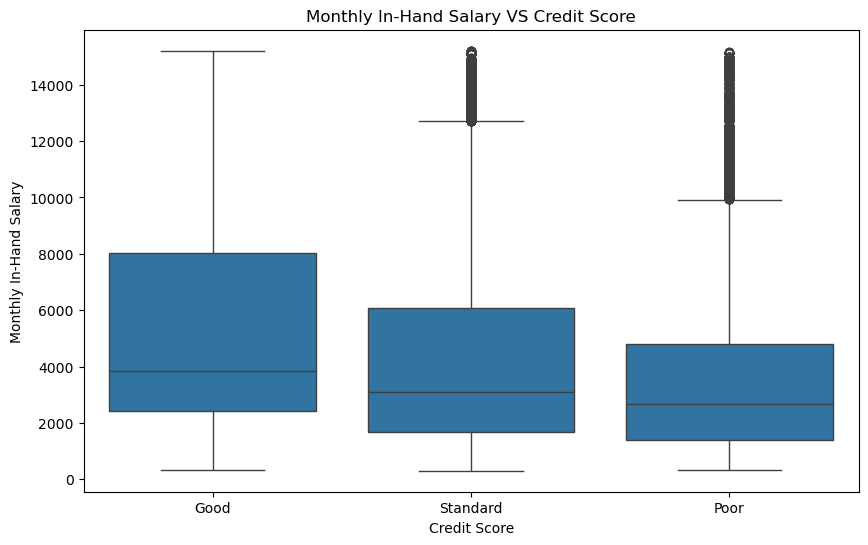

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Credit_Score', y='Monthly_Inhand_Salary', data=paisabazaar_df)
plt.title('Monthly In-Hand Salary VS Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Monthly In-Hand Salary')
plt.show()


##### 1. Why did i pick the specific chart?

Shows how salary variation relates to credit score categories.

##### 2. What is/are the insight(s) found from the chart?

Customers with higher in-hand salaries are more often in the Good credit score group.

##### 3. Will the gained insights help creating a positive business impact?

Demonstrates salary as a predictor of repayment ability and creditworthiness

#### Chart - 6 Comparing Income Distribution of Good VS Poor Credit Score Customers - KDE plot (Income & Salary Insights)

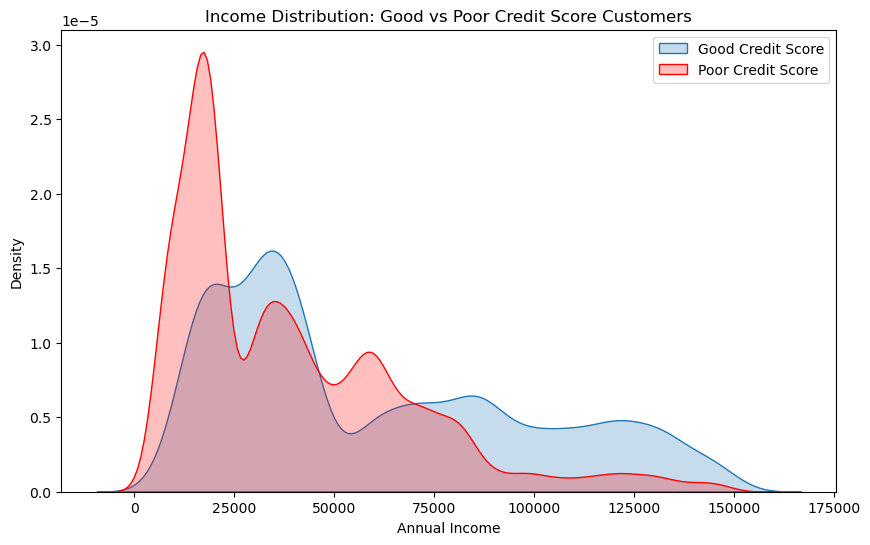

In [45]:
#Compare Income Distribution of Good VS Poor Credit Score Customers - KDE plot
plt.figure(figsize=(10, 6))

# KDE plot for Good credit score customers
sns.kdeplot(df[df['Credit_Score'] == 'Good']['Annual_Income'],
            label='Good Credit Score', shade=True)

# KDE plot for Poor credit score customers
sns.kdeplot(df[df['Credit_Score'] == 'Poor']['Annual_Income'],
            label='Poor Credit Score', shade=True, color='red')

plt.title("Income Distribution: Good vs Poor Credit Score Customers")
plt.xlabel("Annual Income")
plt.ylabel("Density")
plt.legend()
plt.show()

##### 1. Why did i pick the specific chart?

KDE highlights income density differences between groups.

##### 2. What is/are the insight(s) found from the chart?

Good scorers cluster around higher income levels, while poor scorers are more spread in the lower range.

##### 3. Will the gained insights help creating a positive business impact?

Reinforces that income strongly influences repayment and credit risk.

#### Chart - 7 Average Number of Loans VS Credit Score - Bar Chart (Credit & Loans Analysis)

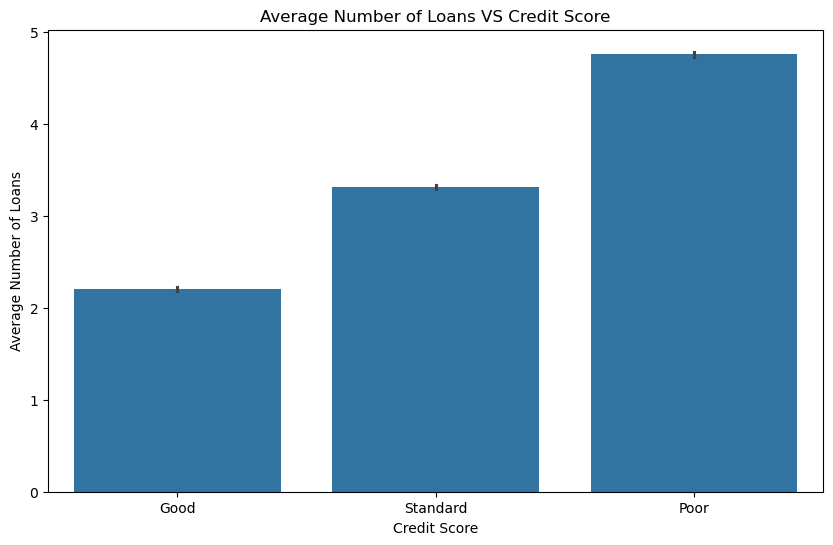

In [46]:
#Average Number of Loans VS Credit Score - Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Credit_Score', y='Num_of_Loan', data=paisabazaar_df)
plt.title('Average Number of Loans VS Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Average Number of Loans')
plt.show()

##### 1. Why did i pick the specific chart?

Simple comparison of averages across categories.

##### 2. What is/are the insight(s) found from the chart?

Poor scorers hold more loans on average than good scorers.

##### 3. Will the gained insights help creating a positive business impact?

Multiple active loans increase default risk; can guide stricter multi-loan approval checks.

#### Chart - 8 Types of Loans Availed by Customers - Stacked Bar Chart (Credit & Loans Analysis)

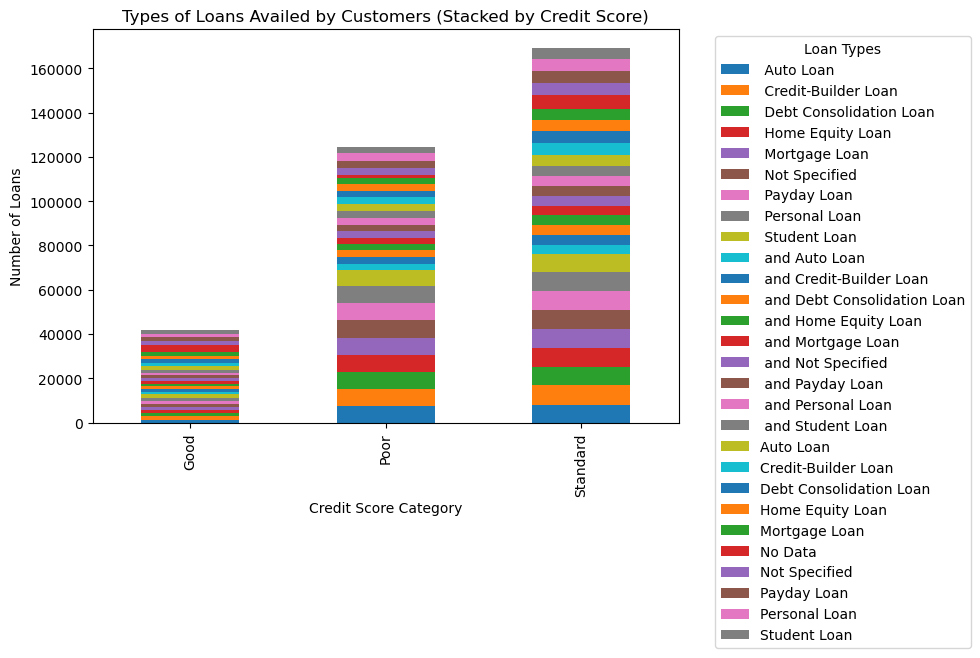

In [47]:
# Split the Type_of_Loan column (loans are separated by commas)
loan_split = paisabazaar_df['Type_of_Loan'].str.get_dummies(sep=',')

# Add Credit Score if you want to analyze loans by score groups
loan_by_score = pd.concat([paisabazaar_df['Credit_Score'], loan_split], axis=1)

# Group by Credit Score and sum
loan_distribution = loan_by_score.groupby('Credit_Score').sum()

# Plot stacked bar chart
loan_distribution.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Types of Loans Availed by Customers (Stacked by Credit Score)")
plt.xlabel("Credit Score Category")
plt.ylabel("Number of Loans")
plt.legend(title="Loan Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 1. Why did i pick the specific chart?

Stacked bar charts are effective for showing how different loan types are distributed across customers.

##### 2. What is/are the insight(s) found from the chart?

Personal loans and credit cards dominate, with customers holding multiple loans often having weaker credit scores.

##### 3. Will the gained insights help creating a positive business impact?


Helps lenders identify over-leveraged customers and control loan approvals accordingly.

#### Chart - 9 Outstanding Debt VS Annual Income(with Credit Score as Color) - Scatter plot (Credit & Loan Analysis)

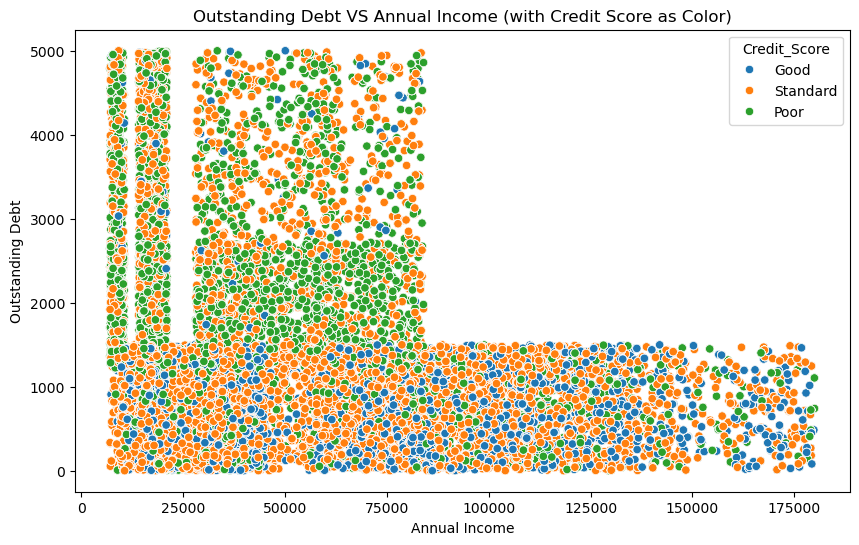

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual_Income', y='Outstanding_Debt', hue='Credit_Score', data=paisabazaar_df)
plt.title('Outstanding Debt VS Annual Income (with Credit Score as Color)')
plt.xlabel('Annual Income')
plt.ylabel('Outstanding Debt')
plt.show()

##### 1. Why did i pick the specific chart?

Best to show relation between income and debt with credit score as color.

##### 2. What is/are the insight(s) found from the chart?

Poor scorers: higher debt at low income.

Good scorers: lower debt, better balance.

Clear trend: higher income → better credit & lower debt.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identify risky low-income/high-debt customers.

Refine loan approvals using debt-to-income ratio.

Target stable customers for premium products.

#### Chart - 10 Number of Delayed Payments VS Credit Score - Box Plot (Risk & Fraud Indicators)

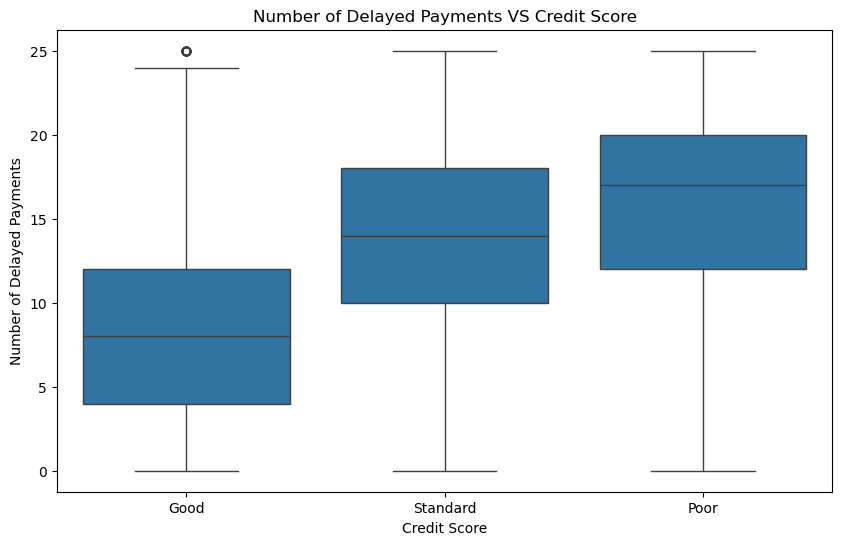

In [49]:
#Number of Delayed Payments VS Credit Score - Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Credit_Score', y='Num_of_Delayed_Payment', data=paisabazaar_df)
plt.title('Number of Delayed Payments VS Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Number of Delayed Payments')
plt.show()

##### 1. Why did i pick the specific chart?

Boxplots capture repayment irregularities per credit score group.

##### 2. What is/are the insight(s) found from the chart?

Poor scorers have a much higher number of delayed payments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Strong evidence that repayment discipline directly impacts credit ratings.

#### Chart - 11 Delay From Due Date Distribution - Histogram & KDE plots (Risk & Fraud Indicator)

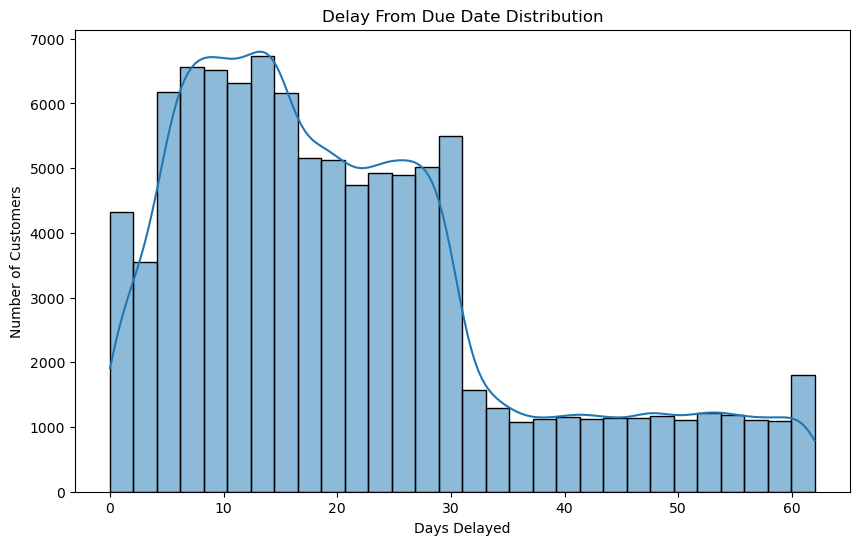

In [50]:
plt.figure(figsize=(10, 6))
sns.histplot(paisabazaar_df['Delay_from_due_date'], bins=30, edgecolor = 'black', kde=True)
plt.title('Delay From Due Date Distribution')
plt.xlabel('Days Delayed')
plt.ylabel('Number of Customers')
plt.show()

##### 1. Why did i pick the specific chart?

Histograms and KDE plots show the frequency and distribution of delays, helping visualize repayment behavior.

##### 2. What is/are the insight(s) found from the chart?

Many customers have consistent payment delays, which correlates with poor credit scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Enables the company to track repayment discipline and set up automated reminders or stricter monitoring for chronic defaulters.

#### Chart - 12 Credit Utilization Ratio Grouped By Credit Score - Bar Chart (Risk & Fraud Indicators)

In [51]:

plt.figure(figsize=(10, 6))
sns.barplot(x='Credit_Utilization_Ratio', y='Credit_Score', data=paisabazaar_df)
plt.title('Credit Utilization Ratio Grouped By Credit Score')
plt.xlabel('Credit Utilization Ratio')
plt.ylabel('Credit Score')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

##### 1. Why did i pick the specific chart?

Clearly shows how utilization varies by group.

##### 2. What is/are the insight(s) found from the chart?

Poor scorers have the highest utilization ratio, while good scorers keep it low.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Can be used as an early-warning KPI to flag risky customers.

#### Chart - 13 Correlation Between Numerical Features - Heatmap (Risk & Fraud Indicator)

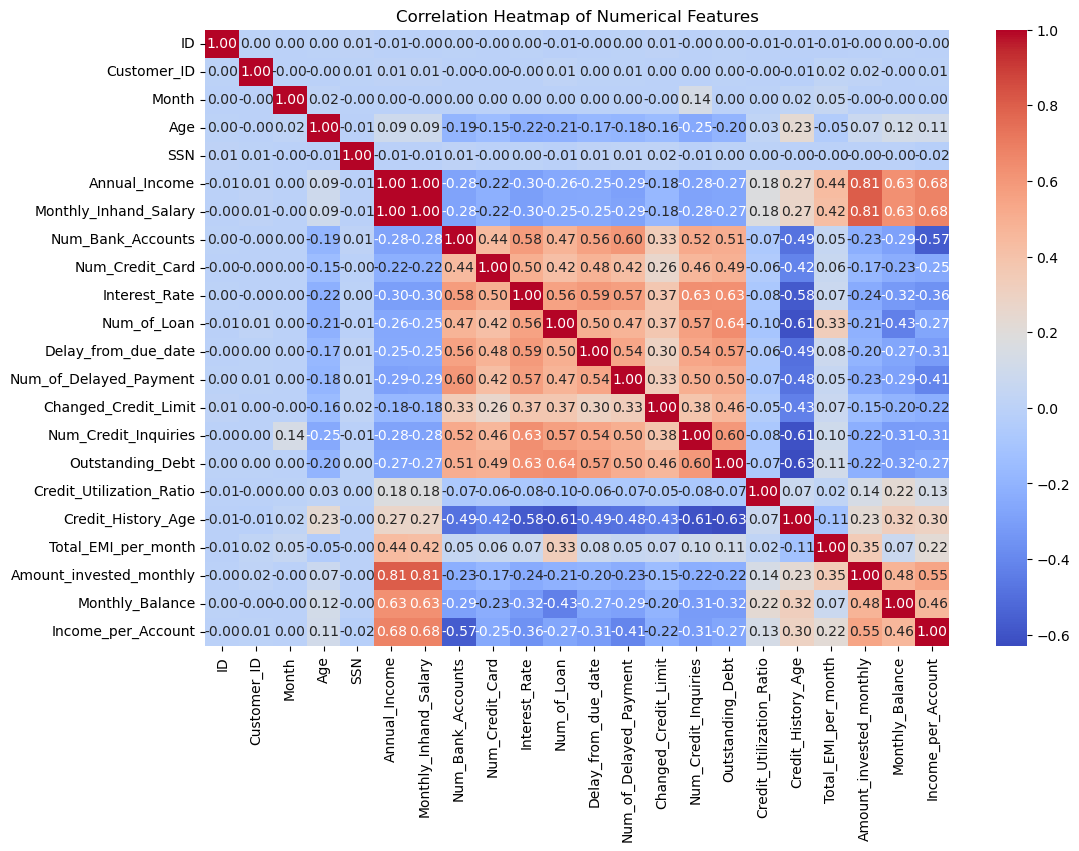

In [59]:
# Select only numerical features
num_df = paisabazaar_df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

##### 1. Why did i pick the specific chart?

Heatmaps are ideal for showing correlations between multiple numerical features.

##### 2. What is/are the insight(s) found from the chart?

Strong positive correlation between Annual Income & Monthly Salary, and between Debt & EMI. Credit Utilization Ratio is strongly tied to credit score.

##### 3. Will the gained insights help creating a positive business impact?


Helps in feature selection for predictive models, reducing redundancy and improving accuracy in fraud detection.

#### Chart - 14 - Payment Behaviour Distribution - Donut Chart (Behavioural Patterns)

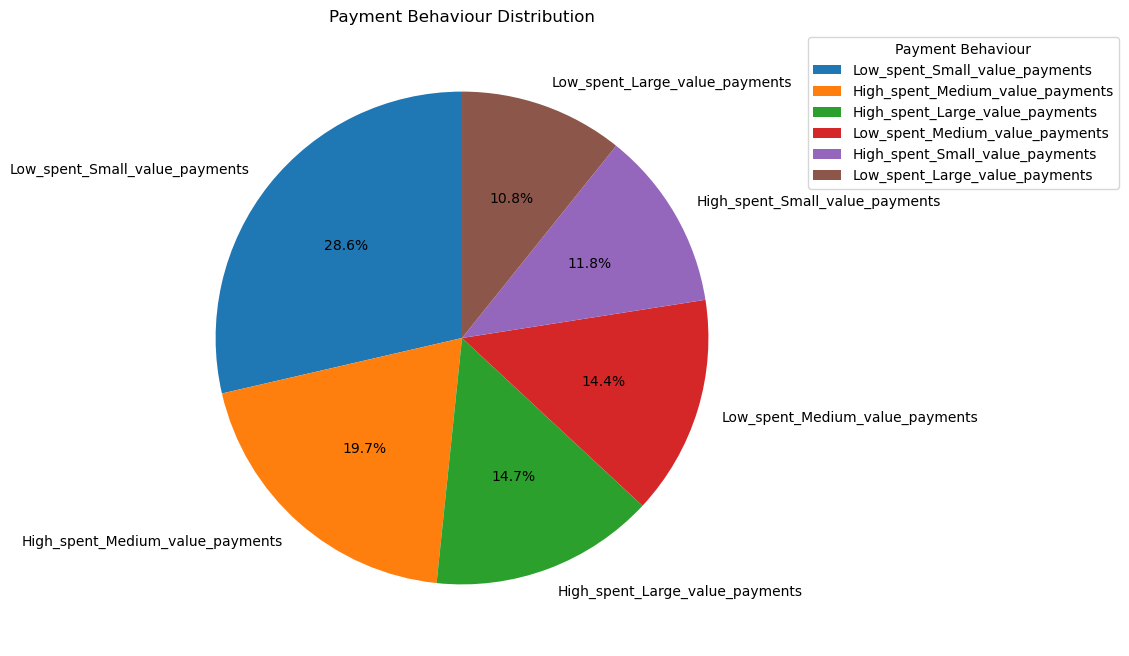

In [53]:
payment_behaviour_counts = paisabazaar_df['Payment_Behaviour'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(payment_behaviour_counts, labels=payment_behaviour_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Payment Behaviour Distribution')


# Add legend
plt.legend(title='Payment Behaviour', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

##### 1. Why did i pick the specific chart?

Pie charts are effective for proportional breakdowns.

##### 2. What is/are the insight(s) found from the chart?

The dataset shows a sizable share of customers with delayed or partial payments.

##### 3. Will the gained insights help creating a positive business impact?


Highlights repayment culture, helping design better repayment reminder systems.

#### Chart - 15 - Payment of Minimum Amount(Yes/No) VS Credit Score - Bar Chart (Behavioural Patterns)

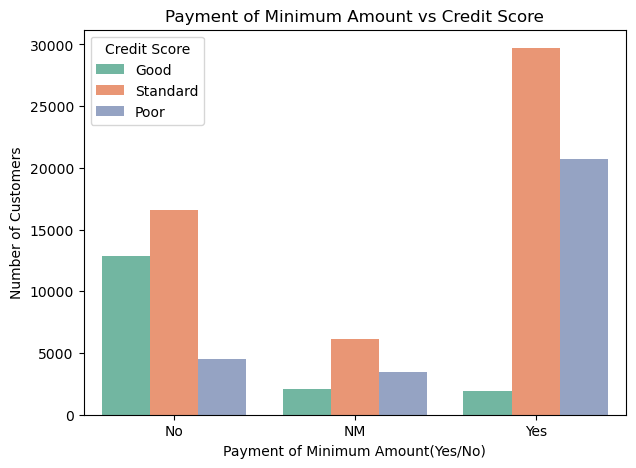

In [54]:
#Payment of Minimum Amount(Yes/No) VS Credit Score - Bar Chart
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Payment_of_Min_Amount', hue='Credit_Score', palette='Set2')

plt.title("Payment of Minimum Amount vs Credit Score")
plt.xlabel("Payment of Minimum Amount(Yes/No)")
plt.ylabel("Number of Customers")
plt.legend(title="Credit Score")
plt.show()

##### 1. Why did i pick the specific chart?

A countplot with hue (Credit Score) clearly shows how repayment habits differ across score categories.

##### 2. What is/are the insight(s) found from the chart?

Customers who only pay the minimum amount are mostly in the Poor score group.

##### 3. Will the gained insights help creating a positive business impact?

Highlights risky repayment habits, allowing financial institutions to flag these customers earlier.

#### Chart - 16 - Payment Behaviour VS Occupation - Stacked Bar Chart (Behavioural Patterns)

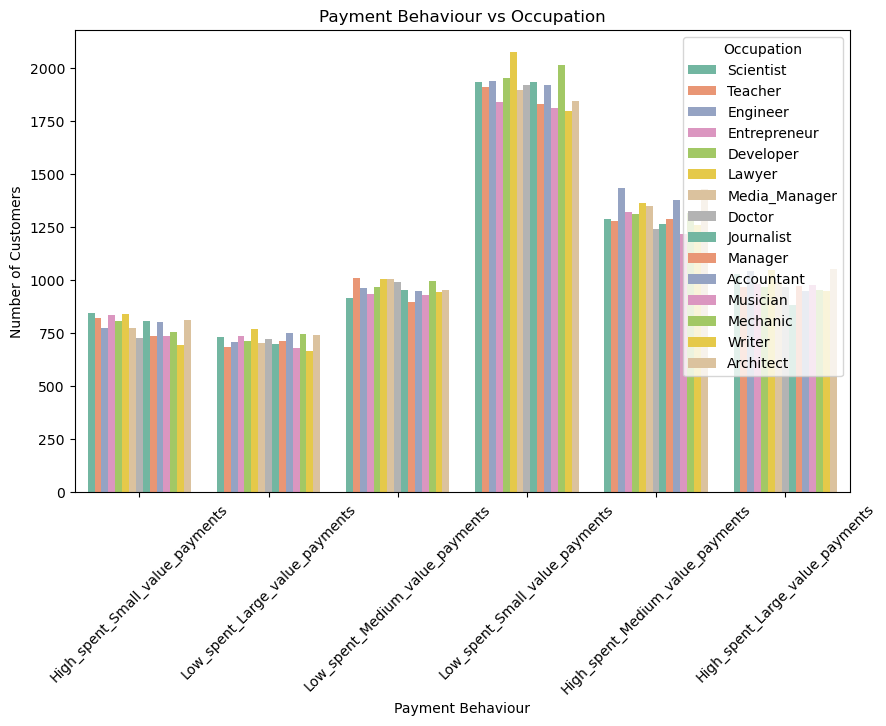

In [55]:

plt.figure(figsize=(10, 6))
sns.countplot(data=paisabazaar_df, x='Payment_Behaviour', hue='Occupation', palette='Set2')
plt.title("Payment Behaviour vs Occupation")
plt.xlabel("Payment Behaviour")
plt.ylabel("Number of Customers")
plt.legend(title="Occupation")
plt.xticks(rotation = 45)
plt.show()

##### 1. Why did i pick the specific chart?

Stacked bars allow cross-comparison of repayment habits by profession.

##### 2. What is/are the insight(s) found from the chart?

Certain occupations are more prone to delayed/partial payments.

##### 3. Will the gained insights help creating a positive business impact?

Helps in occupation-based risk profiling and customized loan eligibility rules.

#### Chart - 17 - Percentage of Customers In Good, Standard, Poor categories - Pie Chart (Overall Credit Score Analysis)

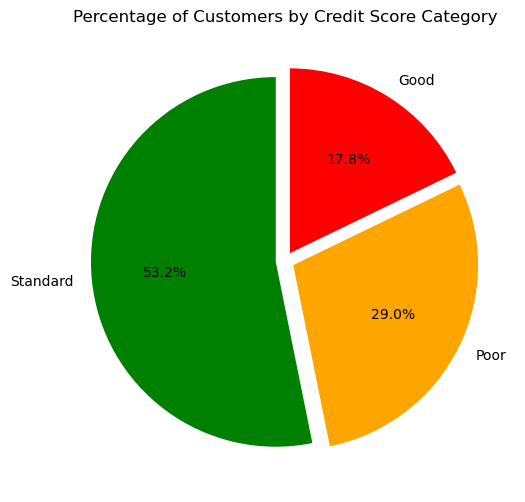

In [56]:
# Count customers in each credit score category
credit_score_counts = paisabazaar_df['Credit_Score'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(credit_score_counts,
        labels=credit_score_counts.index,
         autopct='%1.1f%%',
         startangle=90,
        colors=['green', 'orange', 'red'],
        explode=(0.05, 0.05, 0.05))  # slight separation for clarity

plt.title("Percentage of Customers by Credit Score Category")
plt.show()


##### 1. Why did i pick the specific chart?

A pie chart is best to show the percentage split of customers across Good, Standard, and Poor credit score categories.

##### 2. What is/are the insight(s) found from the chart?

Majority of customers fall under the Standard category, with Poor scorers forming a significant portion, highlighting risk pockets.

##### 3. Will the gained insights help creating a positive business impact?

Helps the bank identify the proportion of high-risk customers, so they can design stricter credit policies and focus retention efforts on good scorers.

#### Chart - 18 - Average Debt, EMI, and Utilization across Credit Score Categories - Bar Chart (Overall Credit Score Analysis)

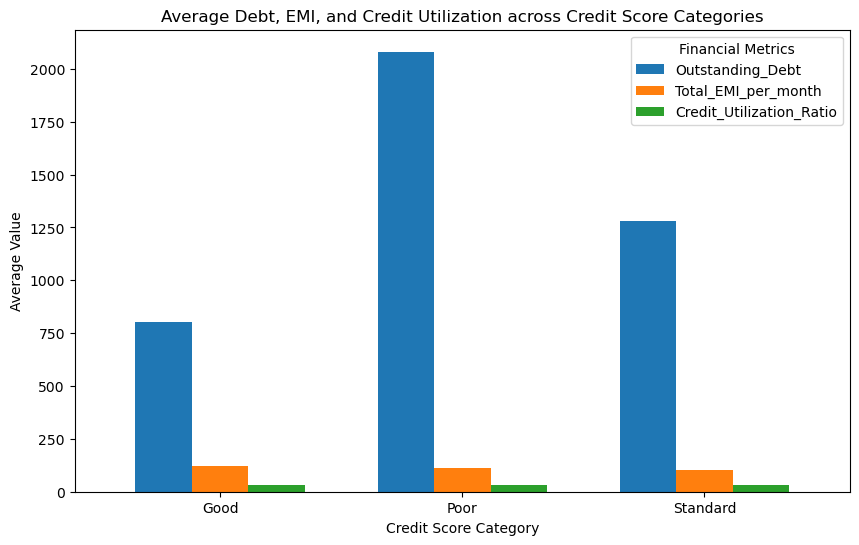

In [57]:
# Calculate averages across Credit Score categories
avg_metrics = paisabazaar_df.groupby('Credit_Score')[['Outstanding_Debt',
                                          'Total_EMI_per_month',
                                          'Credit_Utilization_Ratio']].mean()

# Plot grouped bar chart
avg_metrics.plot(kind='bar', figsize=(10,6), width=0.7)

plt.title("Average Debt, EMI, and Credit Utilization across Credit Score Categories")
plt.xlabel("Credit Score Category")
plt.ylabel("Average Value")
plt.legend(title="Financial Metrics")
plt.xticks(rotation=0)

plt.show()



##### 1. Why did i pick the specific chart?

Grouped bar charts allow simultaneous comparison of multiple financial KPIs across categories.

##### 2. What is/are the insight(s) found from the chart?

Poor scorers consistently have higher EMI and utilization ratios compared to Good scorers.

##### 3. Will the gained insights help creating a positive business impact?

Confirms which financial metrics drive poor credit scores, enabling early warning models and better fraud detection.